In [ ]:
# IMPORTS 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis, PCA
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [3]:
# Show path to csv files
df_2015 = "2015_data.csv"
df_2016 = "2016_data.csv"
df_2017 = "2017_data.csv"
df_2018 = "2018_data.csv"
df_2019 = "2019_data.csv"


# Read csv files through Pandas
data_2015 = pd.read_csv("2015_data.csv")
data_2016 = pd.read_csv("2016_data.csv")
data_2017 = pd.read_csv("2017_data.csv")
data_2018 = pd.read_csv("2018_data.csv")
data_2019 = pd.read_csv("2019_data.csv")

In [4]:
data_2015.head()

,country,region,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,Iceland,Northern Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,Denmark,Northern Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,Norway,Northern Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,Canada,Northern America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [5]:
# Quick sanity check of the structure
print("\n--- Data Shape ---")
print(data_2015.shape)

print("\n--- Data Info (Check for Dtypes and Non-Nulls) ---")
print(data_2015.info())


--- Data Shape ---
(158, 10)

--- Data Info (Check for Dtypes and Non-Nulls) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  158 non-null    object 
 1   region                   158 non-null    object 
 2   happiness_rank           158 non-null    int64  
 3   happiness_score          158 non-null    float64
 4   gdp_per_capita           158 non-null    float64
 5   social_support           158 non-null    float64
 6   healthy_life_expectancy  158 non-null    float64
 7   freedom                  158 non-null    float64
 8   corruption_perception    158 non-null    float64
 9   generosity               158 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 12.5+ KB
None


In [6]:
# Check for Missing Values (Crucial for report "Data Cleaning" section)
missing_values = data_2015.isnull().sum()
print("\n--- Missing Values ---")
print(missing_values[missing_values > 0])


--- Missing Values ---
Series([], dtype: int64)


## Part A: Descriptive Stats & Distribution (Skew/Kurt)

In [22]:
# --- MISSING BLOCK A: DESCRIPTIVE STATS & DISTRIBUTION SHAPE ---
print("\n--- Descriptive Statistics (Mean, Std, IQR) ---")
print(data_2015.describe().to_markdown(numalign="left", stralign="left"))

print("\n--- Skewness and Kurtosis for Distribution Insight ---")
# Skewness: > 1 or < -1 is highly skewed
# Kurtosis: > 3 indicates heavy tails/outliers
stats_df = data_2015.select_dtypes(include=[np.number])
distribution_stats = pd.DataFrame({
    'Skewness': stats_df.skew(),
    'Kurtosis': stats_df.kurt()
})
print(distribution_stats.to_markdown(numalign="left", stralign="left", floatfmt=".3f"))


--- Descriptive Statistics (Mean, Std, IQR) ---
|       | happiness_rank   | happiness_score   | gdp_per_capita   | social_support   | healthy_life_expectancy   | freedom   | corruption_perception   | generosity   |
|:------|:-----------------|:------------------|:-----------------|:-----------------|:--------------------------|:----------|:------------------------|:-------------|
| count | 158              | 158               | 158              | 158              | 158                       | 158       | 158                     | 158          |
| mean  | 79.4937          | 5.37573           | 0.846137         | 0.991046         | 0.630259                  | 0.428615  | 0.143422                | 0.237296     |
| std   | 45.7544          | 1.14501           | 0.403121         | 0.272369         | 0.247078                  | 0.150693  | 0.120034                | 0.126685     |
| min   | 1                | 2.839             | 0                | 0                | 0                       

## Part B: Outlier Detection (The IQR Method)

C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2775434219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='happiness_score', data=data_2015, palette='Spectral')


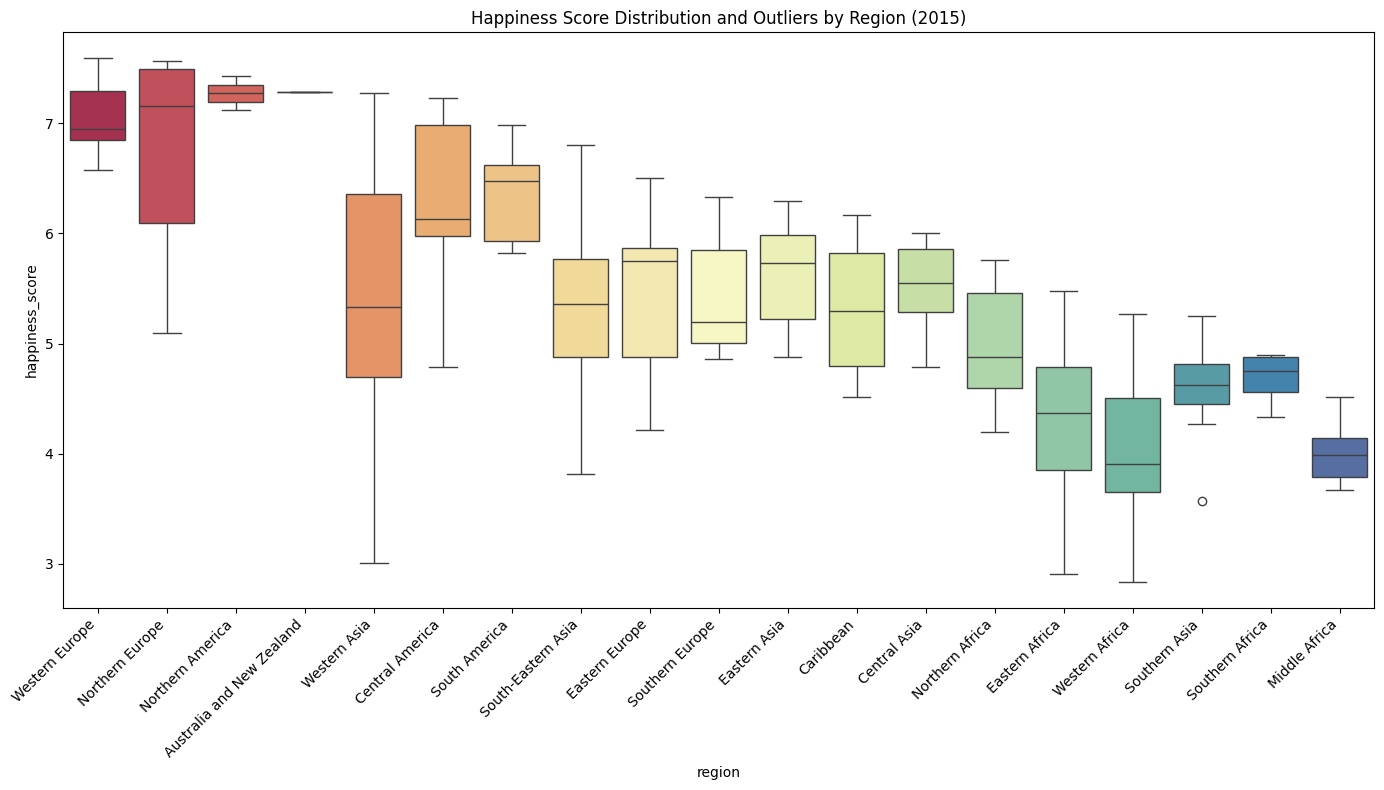

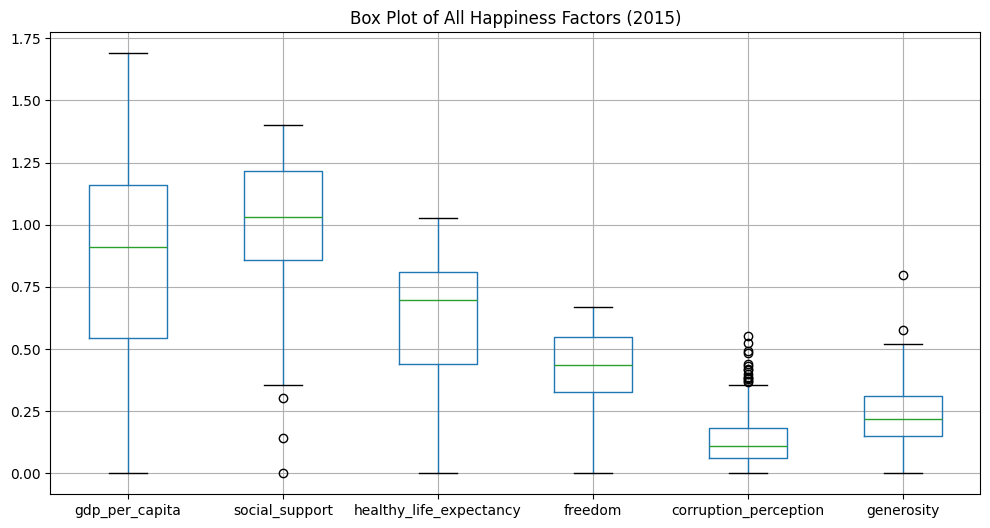

In [23]:
# --- MISSING BLOCK B: OUTLIER DETECTION VIA BOX PLOTS ---
# Box plots by Region for Score (as requested)
plt.figure(figsize=(14, 8))
sns.boxplot(x='region', y='happiness_score', data=data_2015, palette='Spectral')
plt.title('Happiness Score Distribution and Outliers by Region (2015)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional: Generate one box plot for all factors to show outlier scale
data_2015[features].boxplot(figsize=(12, 6))
plt.title('Box Plot of All Happiness Factors (2015)')
plt.show()

## Part C: INDIVIDUAL VARIABLE DEEP DIVES (Top/Bottom 10)



--- Top 10 Countries for: Economy (GDP per Capita) ---
| country              | gdp_per_capita   |
|:---------------------|:-----------------|
| Qatar                | 1.690            |
| Luxembourg           | 1.564            |
| Kuwait               | 1.554            |
| Singapore            | 1.522            |
| Norway               | 1.459            |
| United Arab Emirates | 1.427            |
| Switzerland          | 1.397            |
| Saudi Arabia         | 1.395            |
| United States        | 1.395            |
| Hong Kong            | 1.386            |

--- Bottom 10 Countries for: Economy (GDP per Capita) ---
| country                  | gdp_per_capita   |
|:-------------------------|:-----------------|
| Ethiopia                 | 0.191            |
| Somaliland               | 0.188            |
| Guinea                   | 0.174            |
| Mozambique               | 0.083            |
| Central African Republic | 0.079            |
| Liberia            

C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


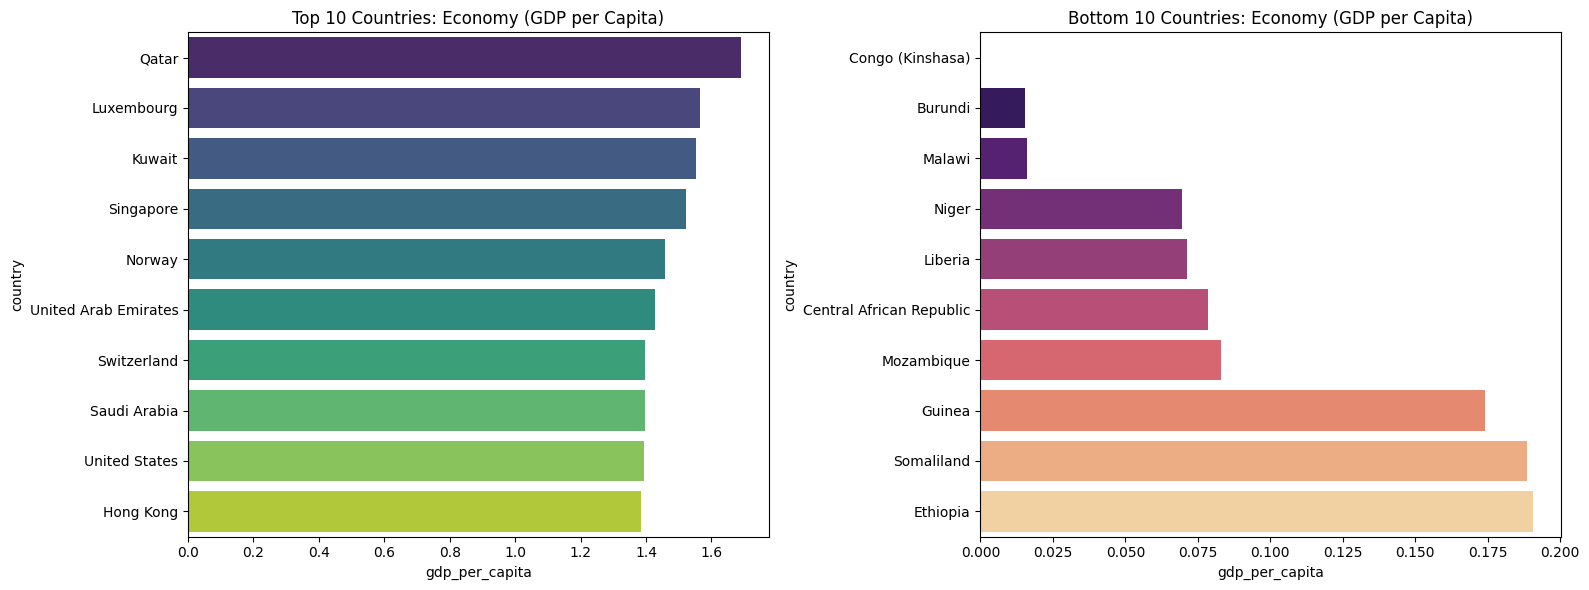


--- Top 10 Countries for: Social Support ---
| country     | social_support   |
|:------------|:-----------------|
| Iceland     | 1.402            |
| Ireland     | 1.369            |
| Denmark     | 1.361            |
| Switzerland | 1.350            |
| Uzbekistan  | 1.340            |
| Norway      | 1.331            |
| Canada      | 1.323            |
| New Zealand | 1.320            |
| Finland     | 1.318            |
| Spain       | 1.314            |

--- Bottom 10 Countries for: Social Support ---
| country                  | social_support   |
|:-------------------------|:-----------------|
| Bangladesh               | 0.431            |
| Burundi                  | 0.416            |
| Pakistan                 | 0.414            |
| Malawi                   | 0.411            |
| Georgia                  | 0.386            |
| India                    | 0.382            |
| Benin                    | 0.354            |
| Afghanistan              | 0.303            |
| Tog

C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


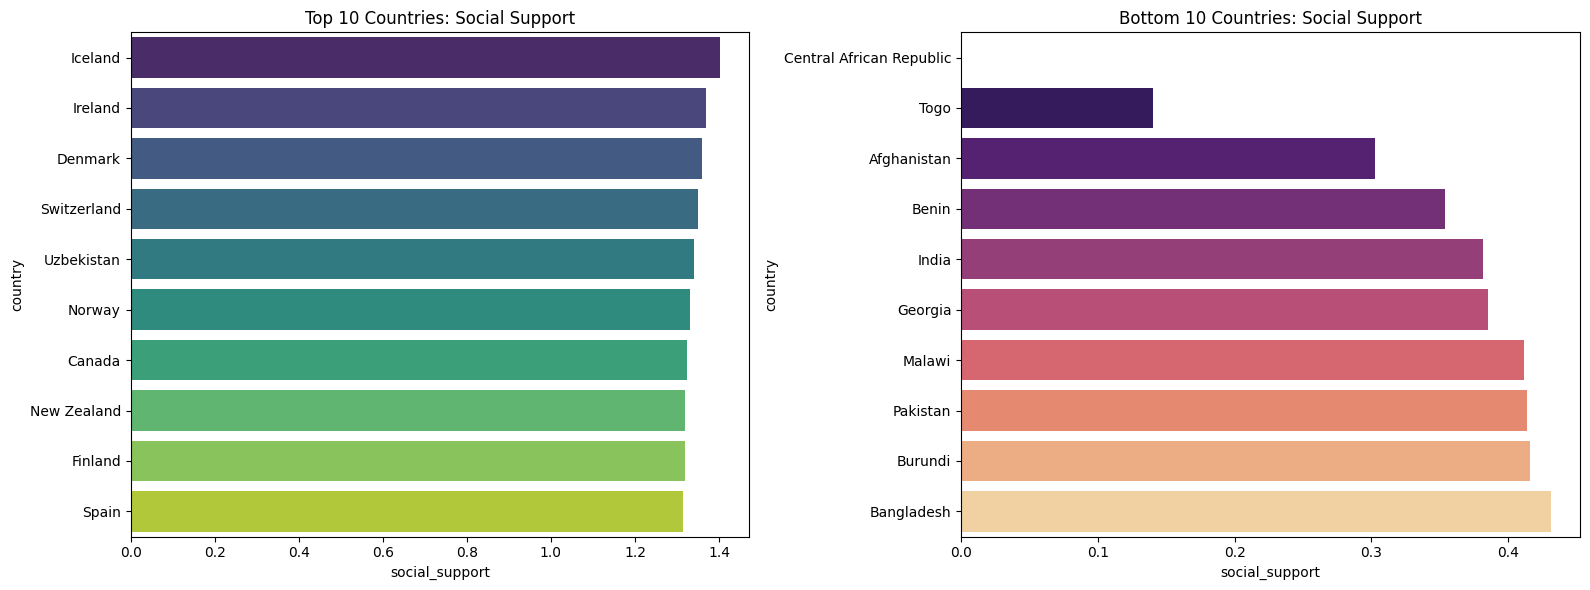


--- Top 10 Countries for: Life Expectancy ---
| country     | healthy_life_expectancy   |
|:------------|:--------------------------|
| Singapore   | 1.025                     |
| Hong Kong   | 1.013                     |
| Japan       | 0.991                     |
| South Korea | 0.965                     |
| Spain       | 0.956                     |
| Italy       | 0.954                     |
| Iceland     | 0.948                     |
| France      | 0.946                     |
| Switzerland | 0.941                     |
| Australia   | 0.932                     |

--- Bottom 10 Countries for: Life Expectancy ---
| country                  | healthy_life_expectancy   |
|:-------------------------|:--------------------------|
| Nigeria                  | 0.160                     |
| Ivory Coast              | 0.152                     |
| Chad                     | 0.150                     |
| Congo (Kinshasa)         | 0.098                     |
| Mozambique               | 0.09

C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


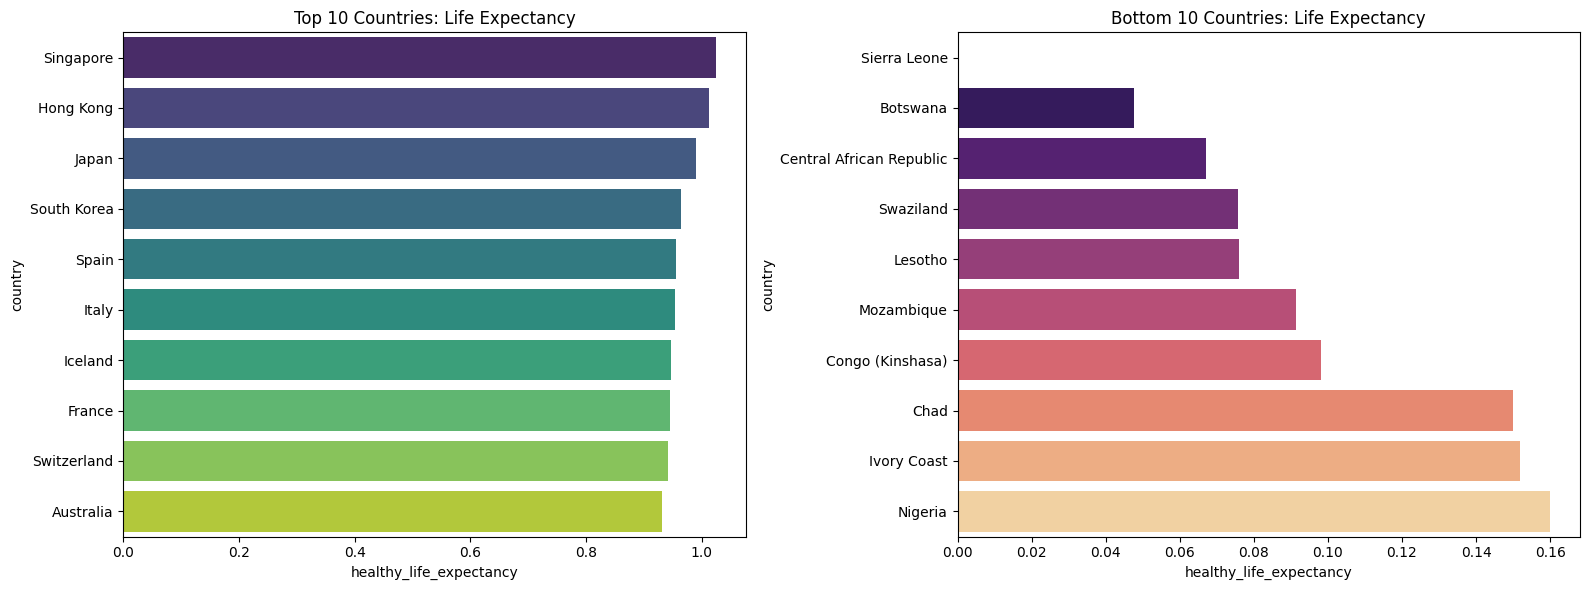


--- Top 10 Countries for: Freedom ---
| country              | freedom   |
|:---------------------|:----------|
| Norway               | 0.670     |
| Switzerland          | 0.666     |
| Cambodia             | 0.662     |
| Sweden               | 0.660     |
| Uzbekistan           | 0.658     |
| Australia            | 0.651     |
| Denmark              | 0.649     |
| Finland              | 0.642     |
| United Arab Emirates | 0.642     |
| Qatar                | 0.640     |

--- Bottom 10 Countries for: Freedom ---
| country                | freedom   |
|:-----------------------|:----------|
| Montenegro             | 0.183     |
| Egypt                  | 0.173     |
| Syria                  | 0.157     |
| Pakistan               | 0.121     |
| Burundi                | 0.118     |
| Angola                 | 0.104     |
| Sudan                  | 0.101     |
| Bosnia and Herzegovina | 0.092     |
| Greece                 | 0.077     |
| Iraq                   | 0.000     |


C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


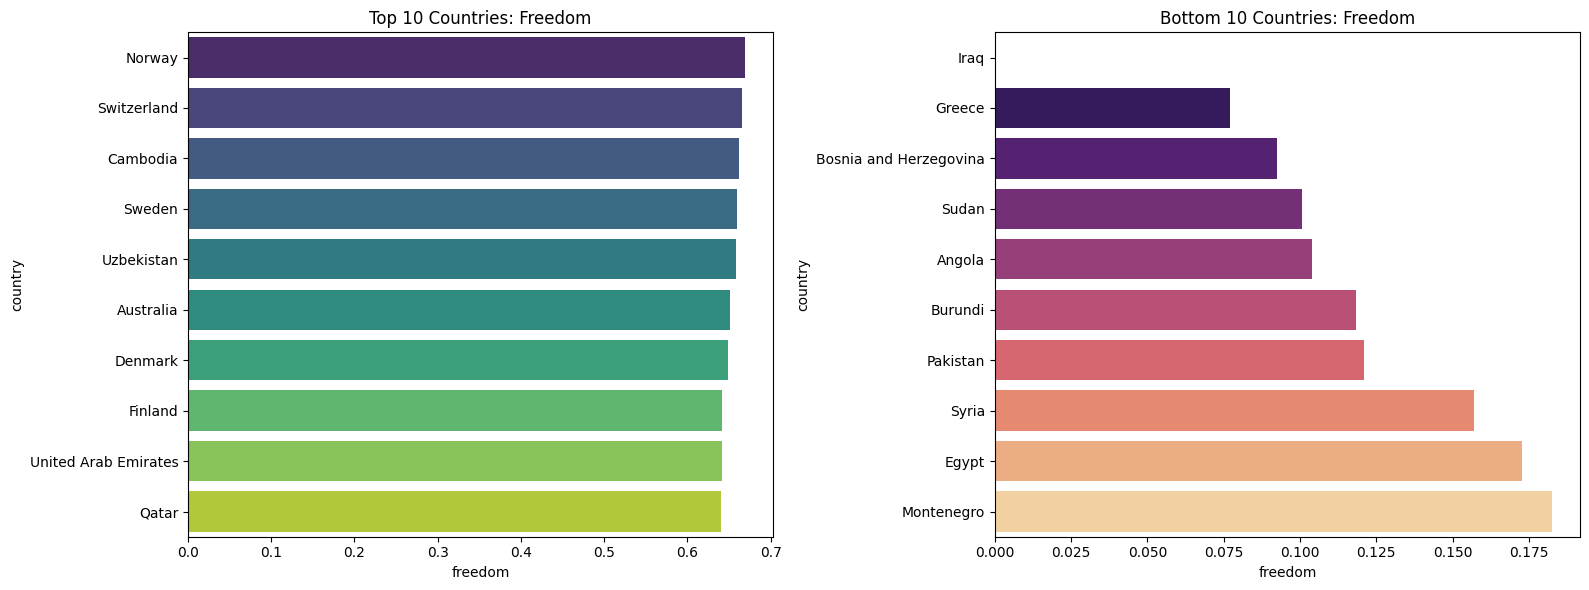


--- Top 10 Countries for: Trust (Gov Corruption) ---
| country              | corruption_perception   |
|:---------------------|:------------------------|
| Rwanda               | 0.552                   |
| Qatar                | 0.522                   |
| Singapore            | 0.492                   |
| Denmark              | 0.484                   |
| Sweden               | 0.438                   |
| New Zealand          | 0.429                   |
| Switzerland          | 0.420                   |
| Finland              | 0.414                   |
| Somaliland           | 0.399                   |
| United Arab Emirates | 0.386                   |

--- Bottom 10 Countries for: Trust (Gov Corruption) ---
| country                | corruption_perception   |
|:-----------------------|:------------------------|
| Jamaica                | 0.023                   |
| Moldova                | 0.016                   |
| Greece                 | 0.014                   |
| Trinidad &

C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


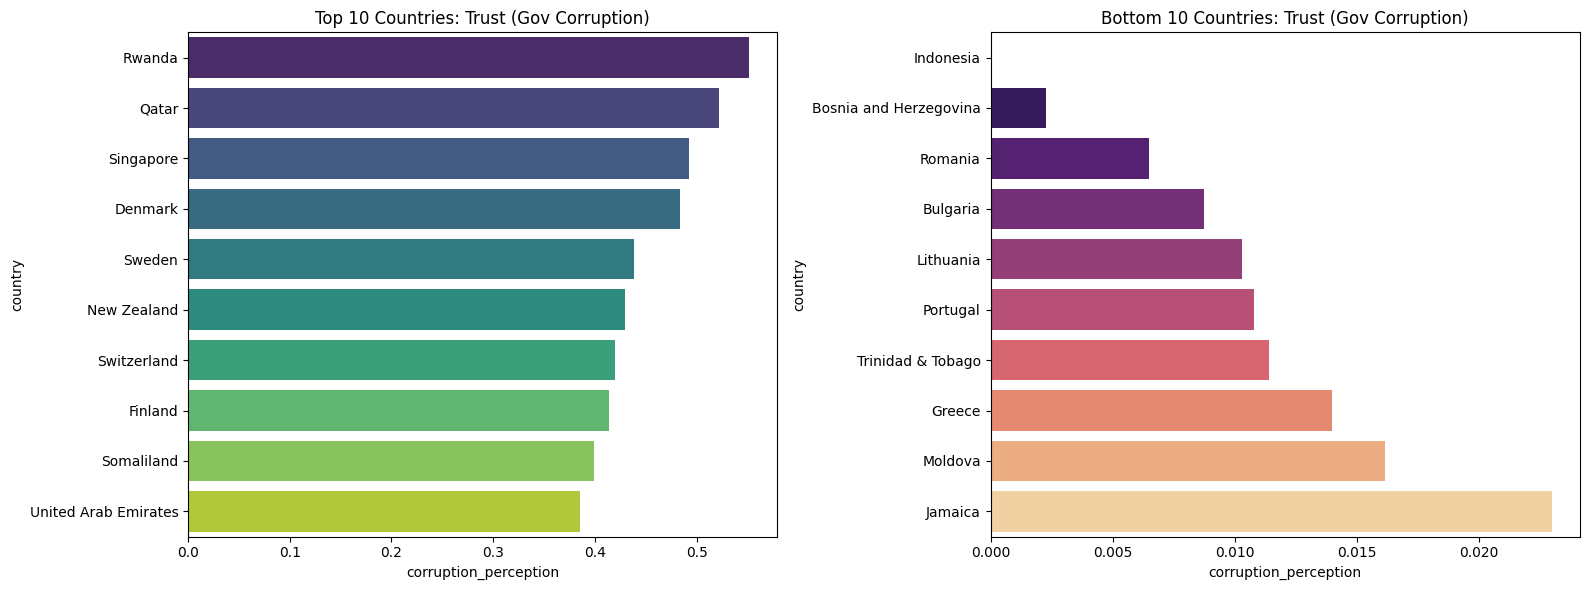


--- Top 10 Countries for: Generosity ---
| country        | generosity   |
|:---------------|:-------------|
| Myanmar        | 0.796        |
| Thailand       | 0.576        |
| United Kingdom | 0.519        |
| Malta          | 0.518        |
| Indonesia      | 0.515        |
| Somaliland     | 0.503        |
| Bhutan         | 0.480        |
| Netherlands    | 0.476        |
| New Zealand    | 0.475        |
| Syria          | 0.472        |

--- Bottom 10 Countries for: Generosity ---
| country    | generosity   |
|:-----------|:-------------|
| Azerbaijan | 0.078        |
| Morocco    | 0.072        |
| Gabon      | 0.068        |
| Tunisia    | 0.064        |
| Venezuela  | 0.058        |
| Georgia    | 0.055        |
| Croatia    | 0.054        |
| Lithuania  | 0.026        |
| Russia     | 0.002        |
| Greece     | 0.000        |


C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
C:\Users\nimit\AppData\Local\Temp\ipykernel_10236\2119471513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')


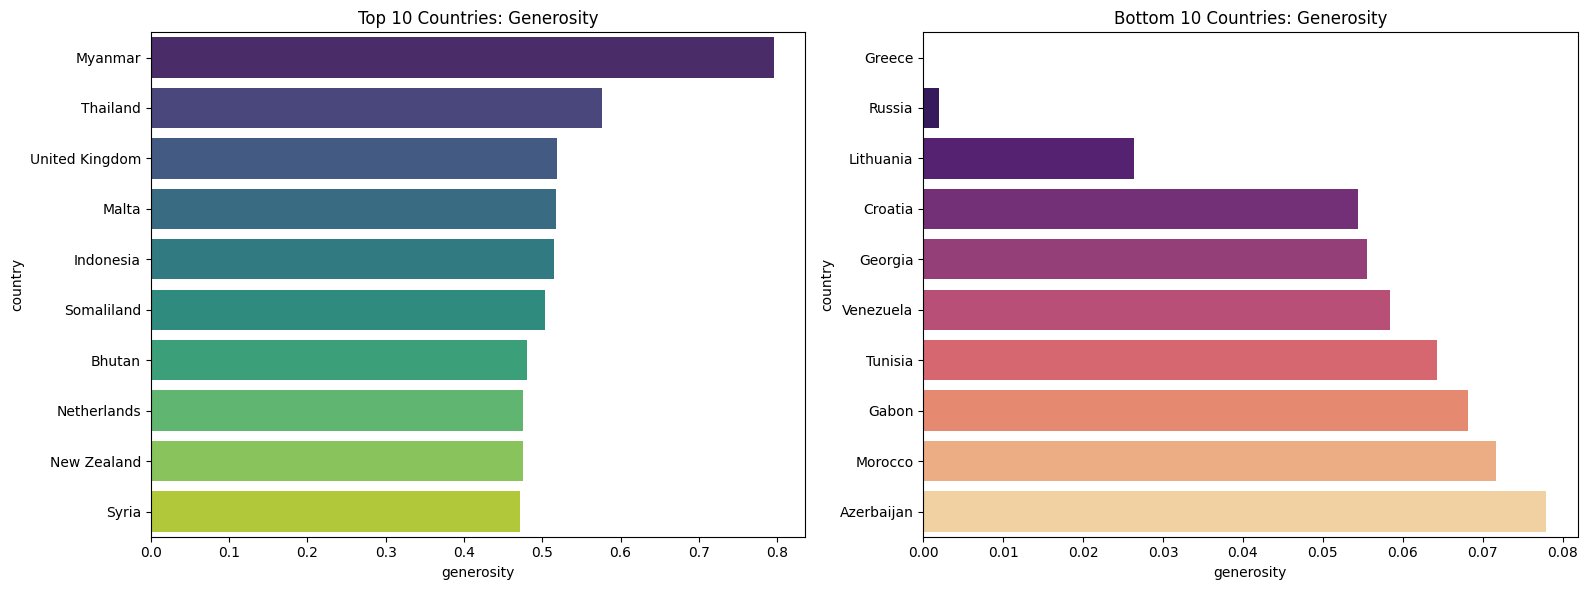

In [ ]:

def analyze_variable_extremes(df, col_name, title_name):
    # Sort data for top/bottom 10
    sorted_df = df.sort_values(by=col_name, ascending=False)
    
    print(f"\n--- Top 10 Countries for: {title_name} ---")
    print(sorted_df[['country', col_name]].head(10).to_markdown(index=False, numalign="left", stralign="left", floatfmt=".3f"))
    
    print(f"\n--- Bottom 10 Countries for: {title_name} ---")
    print(sorted_df[['country', col_name]].tail(10).to_markdown(index=False, numalign="left", stralign="left", floatfmt=".3f"))

    # Optional: Generate bar chart (as in the original draft logic)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Top 10
    sns.barplot(x=col_name, y='country', data=sorted_df.head(10), ax=axes[0], palette='viridis')
    axes[0].set_title(f'Top 10 Countries: {title_name}')
    
    # Plot Bottom 10 (needs to be sorted ascending for visualization)
    bottom_10_plot = sorted_df.tail(10).sort_values(by=col_name, ascending=True)
    sns.barplot(x=col_name, y='country', data=bottom_10_plot, ax=axes[1], palette='magma')
    axes[1].set_title(f'Bottom 10 Countries: {title_name}')
    
    plt.tight_layout()
    plt.show()

# Run the analysis for every independent variable
variables_map = {
    'gdp_per_capita': 'Economy (GDP per Capita)',
    'social_support': 'Social Support',
    'healthy_life_expectancy': 'Life Expectancy',
    'freedom': 'Freedom',
    'corruption_perception': 'Trust (Gov Corruption)',
    'generosity': 'Generosity'
}

for col, title in variables_map.items():
    analyze_variable_extremes(data_2015, col, title)

## 2. UNIVARIATE ANALYSIS (Distributions)


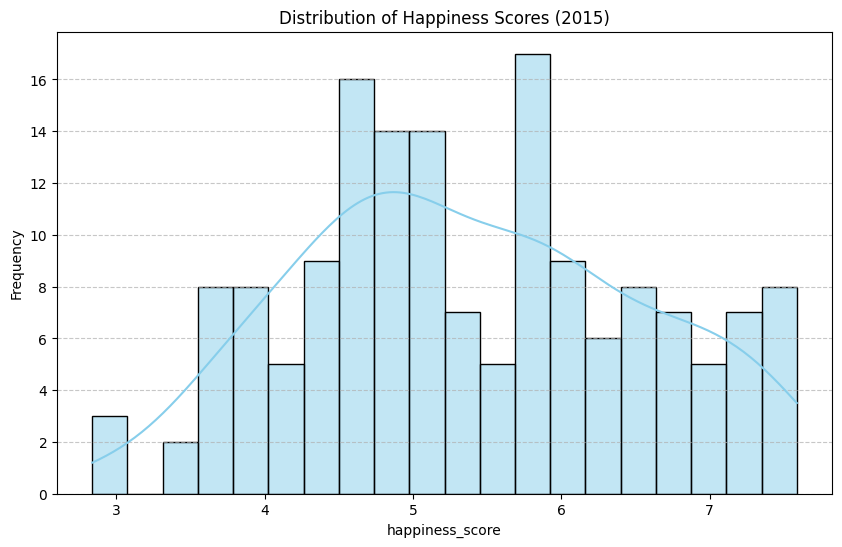

In [ ]:
# We want to see how Happiness Scores are distributed globally in 2015
plt.figure(figsize=(10, 6))
sns.histplot(data_2015['happiness_score'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Happiness Scores (2015)')
plt.xlabel('happiness_score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. BIVARIATE ANALYSIS (Correlations)


In [20]:
# MULTICOLLINEARITY CHECK (VIF)
# Define the columns we are analyzing
features = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 
            'freedom', 'corruption_perception', 'generosity']

vif_data = pd.DataFrame()
vif_data["Feature"] = features
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("\n--- VIF Scores (Check for extreme correlation) ---")
print(vif_data.sort_values('VIF', ascending=False))


--- VIF Scores (Check for extreme correlation) ---
                   Feature       VIF
0           gdp_per_capita  4.078140
2  healthy_life_expectancy  3.157655
1           social_support  1.901853
3                  freedom  1.740443
4    corruption_perception  1.419584
5               generosity  1.268610


## ADVANCED CORRELATION (With P-Values)


--- 2. Advanced Correlation Analysis (R-Values & P-Values) ---

--- Correlation Coefficients (R-Values) ---
                         happiness_score  gdp_per_capita  social_support  \
happiness_score                    1.000           0.781           0.741   
gdp_per_capita                     0.781           1.000           0.645   
social_support                     0.741           0.645           1.000   
healthy_life_expectancy            0.724           0.816           0.531   
freedom                            0.568           0.370           0.442   
corruption_perception              0.395           0.308           0.206   
generosity                         0.180          -0.010           0.088   

                         healthy_life_expectancy  freedom  \
happiness_score                            0.724    0.568   
gdp_per_capita                             0.816    0.370   
social_support                             0.531    0.442   
healthy_life_expectancy               

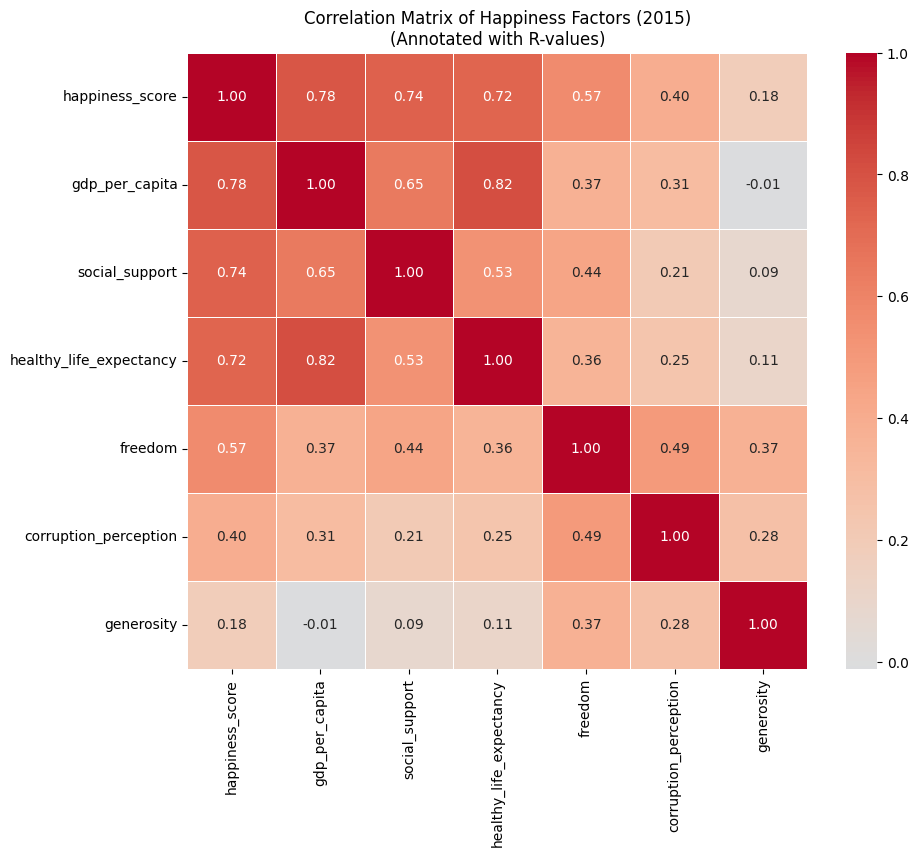

In [ ]:
# Step A: Select variables (Predictors + Target 'happiness_score')
corr_features = ['happiness_score'] + features
df_corr = data_2015[corr_features]

# Step B: Calculate Standard Correlation (Pearson R-values)
r_matrix = df_corr.corr()

# Step C: Calculate P-Values (Statistical Significance)
# This function loops through the matrix to calculate p-value for each pair
def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data()
    cols = df.columns
    p_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
    
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                p_matrix.iloc[i, j] = 0.0 # Correlation with itself is not applicable
            else:
                # stats.pearsonr returns (correlation_coefficient, p_value)
                r, p = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
                p_matrix.iloc[i, j] = p
    return p_matrix

p_matrix = calculate_pvalues(df_corr)

# Step D: Display Tables
print("\n--- Correlation Coefficients (R-Values) ---")
print(r_matrix.round(3))

print("\n--- Statistical Significance (P-Values) ---")
print("Note: Values < 0.05 are statistically significant.")
print(p_matrix.round(4))

# Step E: Generate Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(r_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, center=0)
plt.title('Correlation Matrix of Happiness Factors (2015)\n(Annotated with R-values)')
plt.show()

## Factor Analysis 

In [16]:
# Define the columns we are analyzing
features = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 
            'freedom', 'corruption_perception', 'generosity']

# Create the specific dataframe
df_fa = data_2015[features].copy()

# Standardize the data (CRITICAL: Do this once and reuse 'X_scaled')
X_scaled = StandardScaler().fit_transform(df_fa)

In [17]:
# --- 2. ADEQUACY TESTS (Sanity Checks) ---
# Bartlett's Test (Is there enough correlation?) -> P-value should be < 0.05
chi_square, p_value = calculate_bartlett_sphericity(df_fa)
print(f"Bartlett's Test P-Value: {p_value:.4f}")

# KMO Test (Is the sample size good?) -> Value should be > 0.6
kmo_all, kmo_model = calculate_kmo(df_fa)
print(f"KMO Test Score: {kmo_model:.2f}")

Bartlett's Test P-Value: 0.0000
KMO Test Score: 0.67


C:\Users\nimit\AppData\Roaming\Python\Python314\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


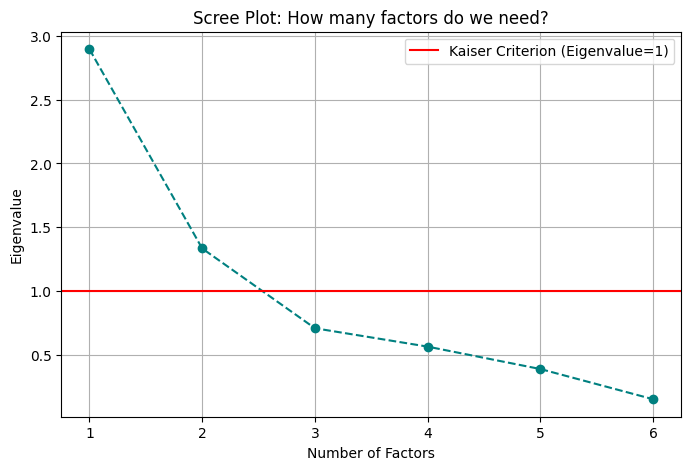

In [18]:
# --- 3. SCREE PLOT (Determine 'N' Factors) ---
# We use PCA for the Scree Plot because it's the standard method for finding N
pca = PCA(n_components=len(features))
pca.fit(X_scaled)
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(features)+1), eigenvalues, marker='o', linestyle='--', color='teal')
plt.axhline(y=1, color='red', linestyle='-', label='Kaiser Criterion (Eigenvalue=1)')
plt.title('Scree Plot: How many factors do we need?')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid()


--- Factor Loadings (The Membership Table) ---
                         Factor 1  Factor 2
gdp_per_capita          -0.974071 -0.131540
social_support          -0.619107 -0.302074
healthy_life_expectancy -0.812633 -0.175087
freedom                 -0.266244 -0.847470
corruption_perception   -0.240803 -0.502527
generosity               0.068065 -0.477071


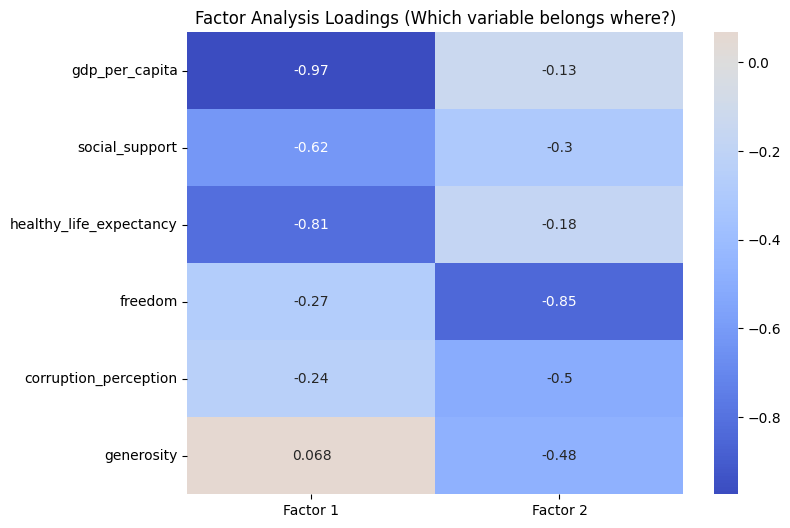

In [19]:
# --- 4. FACTOR ANALYSIS (The Final Model) ---
# Based on the Scree Plot (2 dots above the red line), we choose n_components=2
fa = FactorAnalysis(n_components=2, rotation='varimax', random_state=42)
fa.fit(X_scaled)

# Create the Loadings Table
loadings = pd.DataFrame(
    fa.components_.T, 
    columns=['Factor 1', 'Factor 2'], 
    index=features
)

print("\n--- Factor Loadings (The Membership Table) ---")
print(loadings)

# Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Analysis Loadings (Which variable belongs where?)')
plt.show()